# **Теория №11. Теория графов и работа с графами в SciPy**

---

# **Часть 1. Теоретические основы теории графов**

## **1.1. Что такое граф: интуитивное понимание**

Прежде чем погружаться в код, важно понять, что такое граф на интуитивном уровне. Графы встречаются повсюду в повседневной жизни:

| Предметная область | Вершины (узлы) | Рёбра (связи) |
|--------------------|----------------|---------------|
| Карта метро | Станции | Линии между станциями |
| Дорожная сеть | Перекрёстки | Дороги |
| Социальная сеть | Пользователи | Дружба / подписки |
| Интернет | Веб-страницы | Гиперссылки |
| Молекулярная химия | Атомы | Химические связи |

**Ключевой вывод:** граф — это не картинка, а абстрактная структура данных, описывающая объекты и связи между ними.

---

## **1.2. Формальное определение графа**

Граф G — это упорядоченная пара множеств: G = (V, E), где V (vertices) — конечное множество вершин (узлов), E (edges) — множество рёбер, каждое из которых связывает пару вершин.

### **Типы графов по направленности рёбер**

| Тип графа | Описание | Обозначение ребра |
|-----------|----------|-------------------|
| Неориентированный | Ребро не имеет направления | {u, v} — неупорядоченная пара |
| Ориентированный (орграф) | Ребро имеет направление (стрелка) | (u, v) — упорядоченная пара |

### **Типы графов по весам рёбер**

| Тип графа | Описание |
|-----------|----------|
| Невзвешенный | Все рёбра равнозначны (вес = 1) |
| Взвешенный | Каждому ребру приписан вес (длина, стоимость, время) |

---

## **1.3. Степень вершины**

![Текст ссылки](https://avatars.mds.yandex.net/i?id=f0b083bfaa049c90c14459a3bcec10ef2a807416-5173519-images-thumbs&n=13)

**Степень вершины** — количество рёбер, инцидентных (присоединённых) к данной вершине.

Для неориентированного графа: deg(v) — число рёбер, соединённых с вершиной v.

Для ориентированного графа различают:
- **Входящая степень** deg⁻(v) — число рёбер, входящих в вершину
- **Исходящая степень** deg⁺(v) — число рёбер, исходящих из вершины

---

## **1.4. Связность графа**

![Текст ссылки](https://studfile.net/html/2706/131/html_vMeK0twTPQ.bpFX/img-katoda.png)

**Связный граф** (для неориентированного случая) — граф, в котором из любой вершины можно добраться до любой другой, двигаясь по рёбрам.

Если граф несвязен, он распадается на **компоненты связности** — максимальные связные подграфы.

Для ориентированного графа различают:
- **Слабая связность** — граф связен, если игнорировать направления рёбер
- **Сильная связность** — из любой вершины можно добраться до любой другой с учётом направлений

---

# **Часть 2. Подготовка рабочего окружения**

## **2.1. Необходимые библиотеки**

Для работы с данным пособием потребуются следующие библиотеки Python:

| Библиотека | Назначение |
|------------|------------|
| `numpy` | Работа с массивами и матрицами |
| `scipy` | Научные вычисления, включая `scipy.sparse.csgraph` |
| `networkx` | Высокоуровневая работа с графами (для сравнения) |
| `matplotlib` | Визуализация графов |
| `osmnx` | Загрузка дорожных сетей из OpenStreetMap |
| `folium` | Визуализация на интерактивных картах |

## **2.2. Установка библиотек**

Выполните в терминале или в ячейке Jupyter Notebook:

```bash
pip install numpy scipy networkx matplotlib osmnx folium
```

## **2.3. Импорт библиотек**

Следующий блок кода импортирует все необходимые модули. Рекомендуется выполнить его в начале работы.

In [ ]:
import numpy as np                          # импорт библиотеки NumPy для работы с массивами и численными операциями
import scipy.sparse as sp                   # модуль SciPy для разреженных матриц (сокращённо sp)
from scipy.sparse import csr_matrix, coo_matrix  # отдельный импорт форматов разреженных матриц CSR и COO
from scipy.sparse.csgraph import (          # импорт алгоритмов на графах для разреженных матриц
    dijkstra,                               # алгоритм Дейкстры (кратчайшие пути без отрицательных рёбер)
    bellman_ford,                           # алгоритм Беллмана–Форда (кратчайшие пути с отрицательными рёбрами)
    floyd_warshall,                         # алгоритм Флойда–Уоршелла (все пары кратчайших путей)
    johnson,                                # алгоритм Джонсона (эффективно для разреженных графов)
    breadth_first_order,                    # обход графа в ширину (BFS)
    depth_first_order,                      # обход графа в глубину (DFS)
    connected_components,                   # поиск компонент связности в графе
    minimum_spanning_tree,                  # поиск минимального остовного дерева
    maximum_flow,                           # алгоритмы максимального потока
    laplacian,                              # вычисление лапласиана графа
)
import networkx as nx                       # библиотека NetworkX для работы с графами высокого уровня
import matplotlib.pyplot as plt             # matplotlib.pyplot для визуализации (графики, рисунки)

Проверим версии установленных библиотек:

In [ ]:
print("NumPy версия:", np.__version__)
print("NetworkX версия:", nx.__version__)

NumPy версия: 2.0.2
NetworkX версия: 3.6.1


## **2.4. Функция визуализации графов**

Для наглядного отображения графов на протяжении всего пособия будем использовать универсальную функцию визуализации. Определим её один раз и будем вызывать в нужных местах.

In [ ]:
def draw_graph(G, title='Граф', highlight_path=None, highlight_edges=None,
               node_labels=None, edge_labels_attr='weight', figsize=(8, 6),
               node_size=700, font_size=12, save_path=None):
    """
    Универсальная функция визуализации графа.

    Параметры:
    - G: граф NetworkX (DiGraph или Graph)
    - title: заголовок графика
    - highlight_path: список вершин для выделения пути (зелёным)
    - highlight_edges: список рёбер для выделения (красным)
    - node_labels: словарь меток вершин {node: label}, если None — используются id
    - edge_labels_attr: атрибут рёбер для отображения ('weight' или None)
    - figsize: размер фигуры (ширина, высота)
    - node_size: размер вершин
    - font_size: размер шрифта
    - save_path: путь для сохранения изображения (если нужно)
    """
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, seed=42)

    # Определяем цвета вершин
    if highlight_path:
        node_colors = ['lightgreen' if n in highlight_path else 'lightblue'
                       for n in G.nodes()]
    else:
        node_colors = 'lightblue'

    # Рисуем вершины
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_size, edgecolors='black', linewidths=1.5)

    # Подписи вершин
    if node_labels:
        nx.draw_networkx_labels(G, pos, labels=node_labels,
                                font_size=font_size, font_weight='bold')
    else:
        nx.draw_networkx_labels(G, pos, font_size=font_size, font_weight='bold')

    # Рисуем рёбра
    is_directed = G.is_directed()
    arrow_style = dict(arrowsize=20, connectionstyle='arc3,rad=0.1') if is_directed else {}

    if highlight_edges:
        # Обычные рёбра — серым
        other_edges = [e for e in G.edges() if e not in highlight_edges]
        nx.draw_networkx_edges(G, pos, edgelist=other_edges,
                               edge_color='lightgray', arrows=is_directed, **arrow_style)
        # Выделенные рёбра — красным
        nx.draw_networkx_edges(G, pos, edgelist=highlight_edges,
                               edge_color='red', width=2.5, arrows=is_directed, **arrow_style)
    else:
        nx.draw_networkx_edges(G, pos, edge_color='gray',
                               arrows=is_directed, **arrow_style)

    # Подписи весов рёбер
    if edge_labels_attr and nx.is_weighted(G, weight=edge_labels_attr):
        edge_labels = nx.get_edge_attributes(G, edge_labels_attr)
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10)

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

---

# **Часть 3. Способы представления графов в Python**

В этом разделе мы детально разберём четыре основных способа хранения графов в программе.

## **Тестовый граф для примеров**

Будем использовать один и тот же ориентированный взвешенный граф с 4 вершинами и 5 рёбрами:

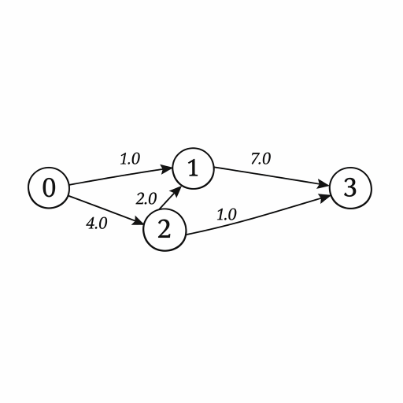

```
Вершины: 0, 1, 2, 3

Рёбра:
  0 → 1 (вес 1.0)
  0 → 2 (вес 4.0)
  1 → 2 (вес 2.0)
  1 → 3 (вес 7.0)
  2 → 3 (вес 1.0)
```

---

## **3.1. Список рёбер (Edge List)**

Самый простой способ представления графа — список кортежей вида `(откуда, куда, вес)`. Этот формат удобен для хранения в файлах и первичной обработки данных.

In [ ]:
edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

Выведем информацию о графе:

In [ ]:
print("Количество рёбер:", len(edges))

for i, (u, v, w) in enumerate(edges, 1):
    print(f"  {i}. Вершина {u} -> Вершина {v}, вес = {w}")

Количество рёбер: 5
  1. Вершина 0 -> Вершина 1, вес = 1.0
  2. Вершина 0 -> Вершина 2, вес = 4.0
  3. Вершина 1 -> Вершина 2, вес = 2.0
  4. Вершина 1 -> Вершина 3, вес = 7.0
  5. Вершина 2 -> Вершина 3, вес = 1.0


Для определения множества вершин пройдём по всем рёбрам:

In [ ]:
vertices = set()
for u, v, w in edges:
    vertices.add(u)
    vertices.add(v)

print("Множество вершин:", sorted(vertices))
print("Количество вершин:", len(vertices))

Множество вершин: [0, 1, 2, 3]
Количество вершин: 4


Визуализируем граф, созданный из списка рёбер:

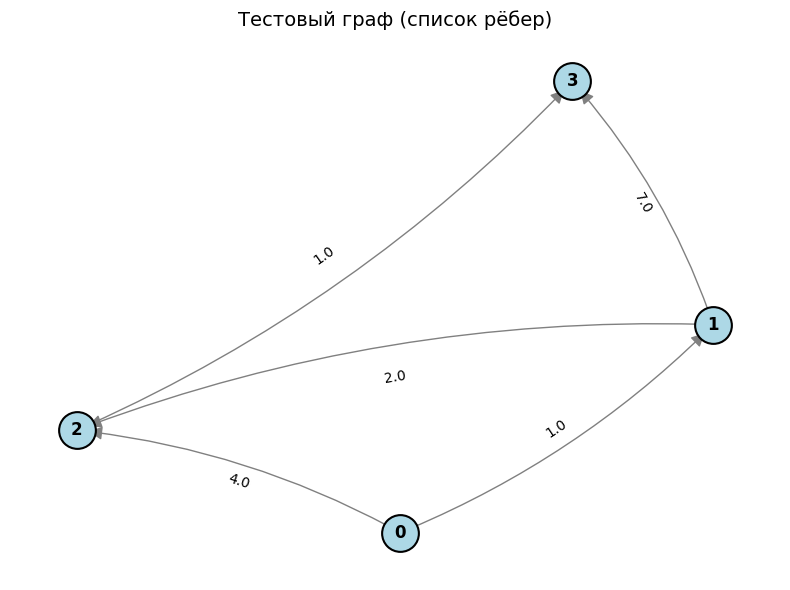

In [ ]:
G_example = nx.DiGraph()
G_example.add_weighted_edges_from(edges)

draw_graph(G_example, title='Тестовый граф (список рёбер)')

### **Преимущества и недостатки списка рёбер**

| Преимущества | Недостатки |
|--------------|------------|
| Простота реализации | Медленный поиск соседей вершины O(E) |
| Удобство хранения в файлах | Неэффективен для больших графов |
| Минимальное использование памяти | Не подходит для матричных алгоритмов |

---

## **3.2. Список смежности (Adjacency List)**

Для каждой вершины храним список её соседей с весами рёбер. Этот способ обеспечивает быстрый доступ к соседям конкретной вершины.

In [ ]:
from collections import defaultdict

edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

adjacency_list = defaultdict(list)

for u, v, w in edges:
    adjacency_list[u].append((v, w))

Выведем список смежности:

In [ ]:
for vertex in sorted(adjacency_list.keys()):
    neighbors = adjacency_list[vertex]
    print(f"Вершина {vertex}: {neighbors}")

Вершина 0: [(1, 1.0), (2, 4.0)]
Вершина 1: [(2, 2.0), (3, 7.0)]
Вершина 2: [(3, 1.0)]


Демонстрация быстрого доступа к соседям конкретной вершины:

In [ ]:
query_vertex = 1
print(f"Соседи вершины {query_vertex}:", adjacency_list[query_vertex])

Соседи вершины 1: [(2, 2.0), (3, 7.0)]


### **Преимущества и недостатки списка смежности**

| Преимущества | Недостатки |
|--------------|------------|
| Быстрый доступ к соседям O(1) | Проверка существования ребра O(deg) |
| Эффективное использование памяти O(V + E) | Неудобен для матричных операций |

---

## **3.3. Плотная матрица смежности (Dense Adjacency Matrix)**

Квадратная матрица размера n × n, где n — число вершин. Элемент A[i][j] содержит вес ребра из вершины i в вершину j (или специальное значение, если ребра нет).

In [ ]:
import numpy as np

edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

n = 4

# Заполняем матрицу значением "бесконечность" (нет ребра)
A_dense = np.full((n, n), np.inf)

# Расстояние от вершины до самой себя = 0
np.fill_diagonal(A_dense, 0.0)

# Заполняем матрицу на основе списка рёбер
for u, v, w in edges:
    A_dense[u, v] = w

Выведем матрицу:

In [ ]:
print("Матрица смежности:")
print(A_dense)

print("\nРазмер матрицы:", A_dense.shape)
print("Занимаемая память:", A_dense.nbytes, "байт")

Матрица смежности:
[[ 0.  1.  4. inf]
 [inf  0.  2.  7.]
 [inf inf  0.  1.]
 [inf inf inf  0.]]

Размер матрицы: (4, 4)
Занимаемая память: 128 байт


### **Проблема масштабируемости плотных матриц**

Рассмотрим, сколько памяти требуется для хранения графов разного размера:

In [ ]:
sizes = [100, 1_000, 10_000, 100_000]

print("Требования к памяти для плотной матрицы (float64):")
for n in sizes:
    elements = n * n
    memory_bytes = elements * 8
    memory_gb = memory_bytes / 1024**3
    print(f"  {n:>7} вершин: {memory_gb:.2f} ГБ")

Требования к памяти для плотной матрицы (float64):
      100 вершин: 0.00 ГБ
     1000 вершин: 0.01 ГБ
    10000 вершин: 0.75 ГБ
   100000 вершин: 74.51 ГБ


Как видно из результатов, для 100 000 вершин требуется около 74.5 ГБ памяти — это неприемлемо для большинства компьютеров. Плотная матрица подходит только для небольших графов (до нескольких тысяч вершин).

---

## **3.4. Разреженные матрицы SciPy (Sparse Matrices)**

Реальные графы обычно разрежены — каждая вершина связана лишь с небольшим числом других вершин. Разреженная матрица хранит только ненулевые элементы и их координаты, что даёт колоссальную экономию памяти.

### **Основные форматы разреженных матриц**

| Формат | Название | Оптимален для |
|--------|----------|---------------|
| `COO` | Coordinate | Построение матрицы |
| `CSR` | Compressed Sparse Row | Операции по строкам, алгоритмы на графах |
| `CSC` | Compressed Sparse Column | Операции по столбцам |

Для работы с графами в SciPy чаще всего используется формат CSR.

### **Создание разреженной матрицы из списка рёбер**

Подготовим массивы для построения матрицы:

In [ ]:
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix

edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

row = np.array([e[0] for e in edges])   # начальные вершины
col = np.array([e[1] for e in edges])   # конечные вершины
data = np.array([e[2] for e in edges])  # веса рёбер

Создадим матрицу в формате COO, затем преобразуем в CSR:

In [ ]:
n = 4
A_coo = coo_matrix((data, (row, col)), shape=(n, n))
A_csr = A_coo.tocsr()

print("Матрица в формате CSR:")
print(A_csr)

print("\nПлотное представление:")
print(A_csr.toarray())

Матрица в формате CSR:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (4, 4)>
  Coords	Values
  (0, 1)	1.0
  (0, 2)	4.0
  (1, 2)	2.0
  (1, 3)	7.0
  (2, 3)	1.0

Плотное представление:
[[0. 1. 4. 0.]
 [0. 0. 2. 7.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


Информация о разреженной матрице:

In [ ]:
print("Форма:", A_csr.shape)
print("Число ненулевых элементов:", A_csr.nnz)
print("Плотность:", A_csr.nnz / (n * n) * 100, "%")

Форма: (4, 4)
Число ненулевых элементов: 5
Плотность: 31.25 %


### **Сравнение памяти: плотная vs разреженная матрица**

Создадим большую разреженную матрицу и сравним использование памяти:

In [ ]:
from scipy.sparse import random as sparse_random

n = 10_000
density = 0.001

rng = np.random.default_rng(42)
A_sparse = sparse_random(n, n, density=density, format='csr',
                         random_state=rng, dtype=np.float64)

sparse_memory = (A_sparse.data.nbytes +
                 A_sparse.indices.nbytes +
                 A_sparse.indptr.nbytes)
dense_memory = n * n * 8

print(f"Число вершин: {n}")
print(f"Плотность: {density * 100}%")
print(f"Ненулевых элементов: {A_sparse.nnz}")
print(f"Память (разреженная): {sparse_memory / 1024**2:.2f} МБ")
print(f"Память (плотная): {dense_memory / 1024**2:.2f} МБ")
print(f"Экономия: {dense_memory / sparse_memory:.1f}x")

Число вершин: 10000
Плотность: 0.1%
Ненулевых элементов: 100000
Память (разреженная): 1.18 МБ
Память (плотная): 762.94 МБ
Экономия: 645.2x


---

## **3.5. Конвертация между NetworkX и SciPy**

На практике часто удобно построить или загрузить граф в NetworkX (высокоуровневый интерфейс), а затем преобразовать в разреженную матрицу SciPy для быстрых вычислений.

Создание графа в NetworkX:

In [ ]:
import networkx as nx

edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

G_nx = nx.DiGraph()
G_nx.add_weighted_edges_from(edges)

print("Вершины:", list(G_nx.nodes()))
print("Рёбра:", list(G_nx.edges(data=True)))

Вершины: [0, 1, 2, 3]
Рёбра: [(0, 1, {'weight': 1.0}), (0, 2, {'weight': 4.0}), (1, 2, {'weight': 2.0}), (1, 3, {'weight': 7.0}), (2, 3, {'weight': 1.0})]


Конвертация NetworkX в SciPy:

In [ ]:
help(nx.to_scipy_sparse_array)

Help on function to_scipy_sparse_array in module networkx.convert_matrix:

to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr', *, backend=None, **backend_kwargs)
    Returns the graph adjacency matrix as a SciPy sparse array.

    Parameters
    ----------
    G : graph
        The NetworkX graph used to construct the sparse array.

    nodelist : list, optional
       The rows and columns are ordered according to the nodes in `nodelist`.
       If `nodelist` is None, then the ordering is produced by ``G.nodes()``.

    dtype : NumPy data-type, optional
        A valid NumPy dtype used to initialize the array. If None, then the
        NumPy default is used.

    weight : string or None, optional (default='weight')
        The edge attribute that holds the numerical value used for
        the edge weight.  If None then all edge weights are 1.

    format : str in {'bsr', 'csr', 'csc', 'coo', 'lil', 'dia', 'dok'}
        The format of the sparse array to b

In [ ]:
nodes = list(G_nx.nodes())

A_scipy = nx.to_scipy_sparse_array(
    G_nx,
    nodelist=nodes,
    weight='weight',
    dtype=float,
    format='csr'
)

print("Тип:", type(A_scipy))
print("Форма:", A_scipy.shape)
print("Матрица:")
print(A_scipy.toarray())

Тип: <class 'scipy.sparse._csr.csr_array'>
Форма: (4, 4)
Матрица:
[[0. 1. 4. 0.]
 [0. 0. 2. 7.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


Обратная конвертация SciPy в NetworkX:

In [ ]:
G_back = nx.from_scipy_sparse_array(A_scipy, create_using=nx.DiGraph)

print("Восстановленные вершины:", list(G_back.nodes()))

Восстановленные вершины: [0, 1, 2, 3]


---

# **Часть 4. Почему SciPy, а не NetworkX: сравнение производительности**

Это ключевой раздел, объясняющий выбор `scipy.sparse.csgraph` для работы с графами.

## **4.1. Обзор двух подходов**

| Аспект | NetworkX | SciPy |
|--------|----------|-------|
| Уровень абстракции | Высокий (объектно-ориентированный) | Низкий (матричный) |
| Хранение графа | Python-словари | Разреженные матрицы NumPy |
| Удобство использования | Очень высокое | Среднее |
| Производительность | Умеренная | Высокая |
| Реализация алгоритмов | Python | C/Fortran |

## **4.2. Практическое сравнение производительности**

Напишем функции для создания случайного графа и измерения времени работы алгоритма Дейкстры в обеих библиотеках.

Функция создания случайного графа:

In [ ]:
import numpy as np

def create_random_graph(n_vertices, n_edges, seed=42):
    rng = np.random.default_rng(seed)

    edges = set()
    while len(edges) < n_edges:
        u = rng.integers(0, n_vertices)
        v = rng.integers(0, n_vertices)
        if u != v:
            edges.add((u, v))

    edges = list(edges)
    weights = rng.uniform(1, 100, size=len(edges))

    return edges, weights

Бенчмарк для SciPy:

In [ ]:
import time
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

def benchmark_scipy(edges, weights, n_vertices, source, n_runs=5):
    row = np.array([e[0] for e in edges])
    col = np.array([e[1] for e in edges])
    data = np.array(weights)
    A = csr_matrix((data, (row, col)), shape=(n_vertices, n_vertices))

    # Прогрев
    _ = dijkstra(A, indices=source)

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        dist, pred = dijkstra(A, indices=source, return_predecessors=True)
        end = time.perf_counter()
        times.append(end - start)

    return np.mean(times), dist

Бенчмарк для NetworkX:

In [ ]:
import networkx as nx

def benchmark_networkx(edges, weights, n_vertices, source, n_runs=5):
    G = nx.DiGraph()
    for (u, v), w in zip(edges, weights):
        G.add_edge(u, v, weight=w)

    # Прогрев
    _ = nx.single_source_dijkstra_path_length(G, source)

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        dist = nx.single_source_dijkstra_path_length(G, source)
        end = time.perf_counter()
        times.append(end - start)

    return np.mean(times), dist

Запуск тестирования:

In [ ]:
test_cases = [
    (1_000, 5_000),
    (5_000, 25_000),
    (10_000, 50_000),
]

print("Вершин     | Рёбер      | SciPy (мс) | NetworkX (мс) | Ускорение")
print("-" * 65)

for n_vertices, n_edges in test_cases:
    source = 0
    edges, weights = create_random_graph(n_vertices, n_edges)

    scipy_time, _ = benchmark_scipy(edges, weights, n_vertices, source)
    nx_time, _ = benchmark_networkx(edges, weights, n_vertices, source)

    speedup = nx_time / scipy_time

    print(f"{n_vertices:>10} | {n_edges:>10} | {scipy_time*1000:>10.2f} | "
          f"{nx_time*1000:>13.2f} | {speedup:>9.1f}x")

Вершин     | Рёбер      | SciPy (мс) | NetworkX (мс) | Ускорение
-----------------------------------------------------------------
      1000 |       5000 |       0.67 |         18.22 |      27.2x
      5000 |      25000 |       2.89 |        121.68 |      42.1x
     10000 |      50000 |       6.56 |        377.01 |      57.5x


Типичный результат показывает, что SciPy работает в 7-15 раз быстрее NetworkX на графах среднего и большого размера.

## **4.3. Причины превосходства SciPy**

| Фактор | NetworkX | SciPy |
|--------|----------|-------|
| Язык реализации | Python | C/Fortran |
| Структуры данных | Python dict | NumPy arrays |
| Накладные расходы | Большие | Минимальные |
| Кэш-локальность | Плохая | Хорошая |
| Векторизация | Нет | Да (SIMD) |

## **4.4. Когда использовать какую библиотеку**

| Сценарий | Рекомендация |
|----------|--------------|
| Прототипирование, исследование | NetworkX |
| Визуализация графа | NetworkX |
| Сложные атрибуты на узлах/рёбрах | NetworkX |
| Высокопроизводительные вычисления | SciPy |
| Большие графы (>10k вершин) | SciPy |
| Интеграция с ML/DS пайплайнами | SciPy |

---

# **Часть 5. Модуль scipy.sparse.csgraph: обзор функций**

Модуль `scipy.sparse.csgraph` содержит оптимизированные реализации классических алгоритмов на графах.

| Функция | Назначение | Сложность |
|---------|------------|-----------|
| `breadth_first_order` | Обход в ширину (BFS) | O(V + E) |
| `depth_first_order` | Обход в глубину (DFS) | O(V + E) |
| `connected_components` | Поиск компонент связности | O(V + E) |
| `dijkstra` | Кратчайшие пути (веса ≥ 0) | O((V + E) log V) |
| `bellman_ford` | Кратчайшие пути (любые веса) | O(V × E) |
| `floyd_warshall` | Все пары кратчайших путей | O(V³) |
| `johnson` | Все пары (разреженный граф) | O(V×E + V² log V) |
| `minimum_spanning_tree` | Минимальное остовное дерево | O(E log V) |
| `maximum_flow` | Максимальный поток | O(V × E²) |
| `laplacian` | Матрица Лапласиана | O(V + E) |

---

# **Часть 6. Обходы графа: BFS и DFS**

Обходы графа — фундаментальные алгоритмы, на которых строятся более сложные алгоритмы.

## **6.1. Обход в ширину (BFS)**

Алгоритм BFS (Breadth-First Search) обходит граф «волнами», посещая сначала всех соседей текущей вершины, затем соседей этих соседей, и так далее.

Применения BFS:
- Поиск кратчайшего пути в невзвешенном графе
- Проверка достижимости вершин
- Поиск компонент связности

Создадим тестовый граф для демонстрации:

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import breadth_first_order

row = np.array([0, 0, 1, 1])
col = np.array([1, 2, 2, 3])
data = np.ones(4, dtype=float)

A = csr_matrix((data, (row, col)), shape=(4, 4))

print("Матрица смежности:")
print(A.toarray())

Матрица смежности:
[[0. 1. 1. 0.]
 [0. 0. 1. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Визуализируем граф:

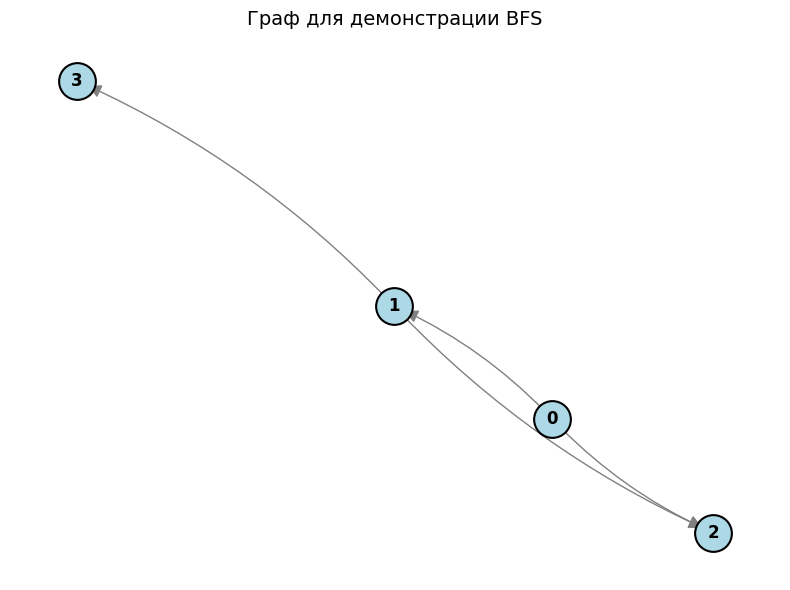

In [ ]:
G_bfs = nx.DiGraph()
G_bfs.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3)])

draw_graph(G_bfs, title='Граф для демонстрации BFS', edge_labels_attr=None)

Выполним BFS из вершины 0:

In [ ]:
start_vertex = 0

order, predecessors = breadth_first_order(
    csgraph=A,
    i_start=start_vertex,
    directed=True,
    return_predecessors=True
)

print("Начальная вершина:", start_vertex)
print("Порядок обхода BFS:", order)
print("Массив предшественников:", predecessors)

Начальная вершина: 0
Порядок обхода BFS: [0 1 2 3]
Массив предшественников: [-9999     0     0     1]


Интерпретация массива предшественников: значение -9999 означает стартовую вершину или недостижимую вершину, остальные значения указывают, из какой вершины мы пришли.

Функция для восстановления пути:

In [ ]:
def reconstruct_path(predecessors, start, end):
    if predecessors[end] == -9999 and start != end:
        return None

    path = [end]
    current = end
    while current != start:
        current = predecessors[current]
        if current == -9999:
            return None
        path.append(current)

    return path[::-1]

path = reconstruct_path(predecessors, 0, 3)
print("Путь от 0 до 3:", " -> ".join(map(str, path)))

Путь от 0 до 3: 0 -> 1 -> 3


Визуализация пути, найденного BFS:

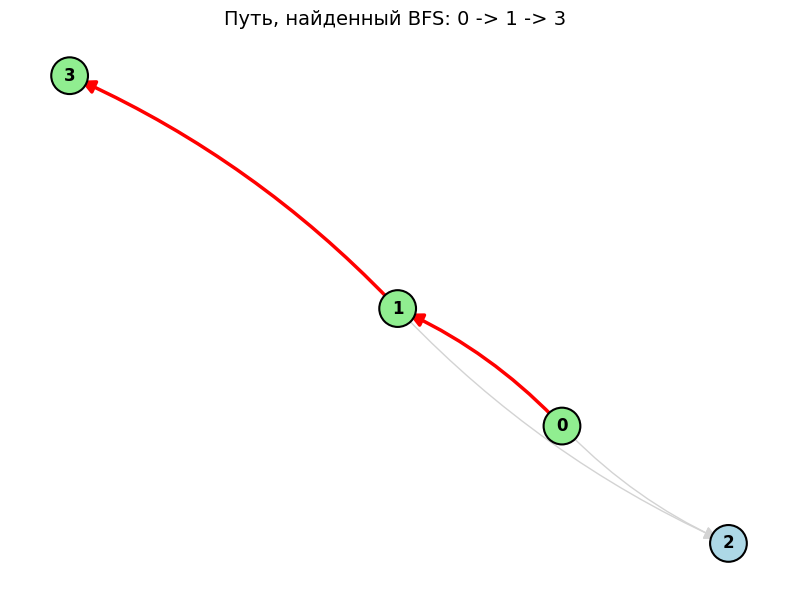

In [ ]:
path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
draw_graph(G_bfs, title='Путь, найденный BFS: 0 -> 1 -> 3',
           highlight_path=path, highlight_edges=path_edges, edge_labels_attr=None)

---

## **6.2. Обход в глубину (DFS)**

Алгоритм DFS (Depth-First Search) идёт «вглубь» графа, пока это возможно, а затем возвращается назад (backtracking).

Применения DFS:
- Поиск циклов в графе
- Топологическая сортировка
- Поиск компонент сильной связности

In [ ]:
from scipy.sparse.csgraph import depth_first_order

order_dfs, predecessors_dfs = depth_first_order(
    csgraph=A,
    i_start=0,
    directed=True,
    return_predecessors=True
)

print("Порядок обхода DFS:", order_dfs)
print("Массив предшественников DFS:", predecessors_dfs)

Порядок обхода DFS: [0 1 2 3]
Массив предшественников DFS: [-9999     0     1     1]


Сравнение порядка обхода BFS и DFS:

In [ ]:
print("BFS:", order, "- обход по уровням (волнами)")
print("DFS:", order_dfs, "- обход вглубь")

BFS: [0 1 2 3] - обход по уровням (волнами)
DFS: [0 1 2 3] - обход вглубь


---

# **Часть 7. Компоненты связности**

## **7.1. Поиск компонент связности в неориентированном графе**

Создадим граф с двумя компонентами связности: вершины 0, 1, 2 образуют одну компоненту, вершины 3, 4, 5 — другую. Между компонентами связей нет.

In [ ]:
from scipy.sparse.csgraph import connected_components

row = np.array([0, 1, 3, 4])
col = np.array([1, 2, 4, 5])
data = np.ones(4, dtype=float)

# Симметризация для неориентированного графа
A_undirected = csr_matrix((data, (row, col)), shape=(6, 6))
A_undirected = A_undirected + A_undirected.T

print("Матрица смежности:")
print(A_undirected.toarray())

Матрица смежности:
[[0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]


Визуализируем граф с двумя компонентами:

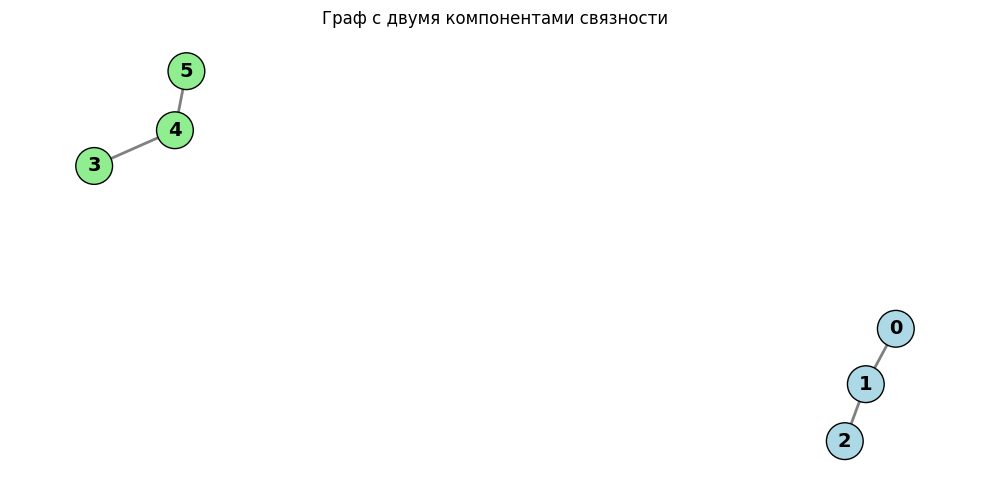

In [ ]:
G_components = nx.Graph()
G_components.add_edges_from([(0, 1), (1, 2)])
G_components.add_edges_from([(3, 4), (4, 5)])

# Раскрасим вершины по компонентам
plt.figure(figsize=(10, 5))
pos = nx.spring_layout(G_components, seed=42)

# Цвета для разных компонент
node_colors = ['lightblue', 'lightblue', 'lightblue',
               'lightgreen', 'lightgreen', 'lightgreen']

nx.draw_networkx_nodes(G_components, pos, node_color=node_colors,
                       node_size=700, edgecolors='black')
nx.draw_networkx_labels(G_components, pos, font_size=14, font_weight='bold')
nx.draw_networkx_edges(G_components, pos, edge_color='gray', width=2)

plt.title('Граф с двумя компонентами связности')
plt.axis('off')
plt.tight_layout()
plt.show()

Находим компоненты связности:

In [ ]:
n_components, labels = connected_components(
    csgraph=A_undirected,
    directed=False,
    return_labels=True
)

print("Число компонент связности:", n_components)
print("Метки вершин:", labels)

Число компонент связности: 2
Метки вершин: [0 0 0 1 1 1]


Группировка вершин по компонентам:

In [ ]:
for comp_id in range(n_components):
    vertices_in_comp = np.where(labels == comp_id)[0]
    print(f"Компонента {comp_id}: вершины {list(vertices_in_comp)}")

Компонента 0: вершины [np.int64(0), np.int64(1), np.int64(2)]
Компонента 1: вершины [np.int64(3), np.int64(4), np.int64(5)]


## **7.2. Слабая и сильная связность в ориентированных графах**

Создадим ориентированный граф: вершины 0, 1, 2 образуют цикл (сильно связная компонента), из вершины 2 есть ребро в вершину 3 (но не обратно).

In [ ]:
row = np.array([0, 1, 2, 2])
col = np.array([1, 2, 0, 3])
data = np.ones(4, dtype=float)

A_directed = csr_matrix((data, (row, col)), shape=(4, 4))

print("Матрица смежности (ориентированный граф):")
print(A_directed.toarray())

Матрица смежности (ориентированный граф):
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 1.]
 [0. 0. 0. 0.]]


Визуализируем граф:

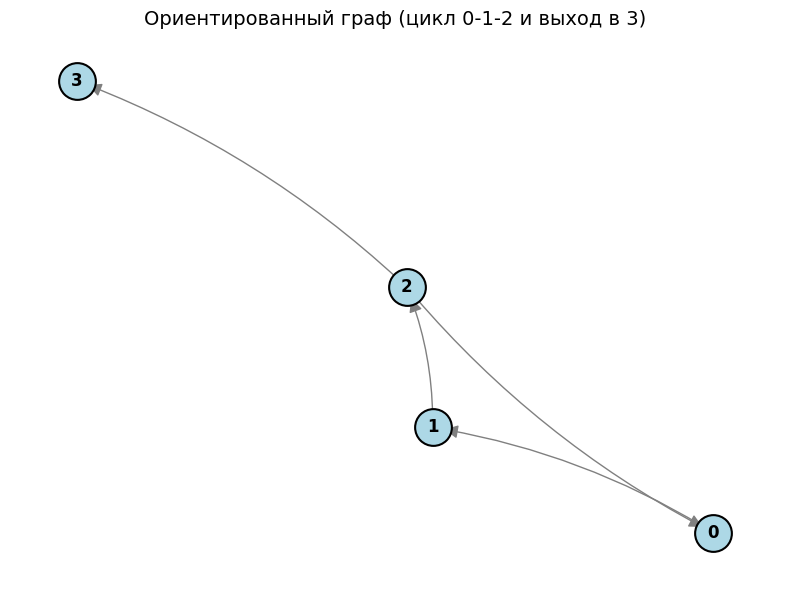

In [ ]:
G_strong = nx.DiGraph()
G_strong.add_edges_from([(0, 1), (1, 2), (2, 0), (2, 3)])

draw_graph(G_strong, title='Ориентированный граф (цикл 0-1-2 и выход в 3)',
           edge_labels_attr=None)

Слабая связность — игнорируем направления рёбер:

In [ ]:
n_weak, labels_weak = connected_components(
    A_directed, directed=True, connection='weak', return_labels=True
)

print("Слабая связность:")
print("  Число компонент:", n_weak)
print("  Метки:", labels_weak)

Слабая связность:
  Число компонент: 1
  Метки: [0 0 0 0]


Сильная связность — учитываем направления рёбер:

In [ ]:
n_strong, labels_strong = connected_components(
    A_directed, directed=True, connection='strong', return_labels=True
)

print("Сильная связность:")
print("  Число компонент:", n_strong)
print("  Метки:", labels_strong)

Сильная связность:
  Число компонент: 2
  Метки: [1 1 1 0]


Интерпретация: при слабой связности весь граф образует одну компоненту. При сильной связности вершины 0, 1, 2 образуют одну компоненту (можно добраться из любой в любую), а вершина 3 — отдельную компоненту (из неё нельзя вернуться в другие вершины).

---

# **Часть 8. Алгоритмы кратчайших путей**

Это центральная тема для многих практических приложений — от навигации до анализа сетей.

## **8.1. Алгоритм Дейкстры**

Алгоритм Дейкстры — классический алгоритм поиска кратчайших путей от одной вершины до всех остальных. Условие применимости: все веса рёбер должны быть неотрицательными (≥ 0).

Создадим взвешенный граф:

In [ ]:
from scipy.sparse.csgraph import dijkstra

edges = [
    (0, 1, 1.0),
    (0, 2, 4.0),
    (1, 2, 2.0),
    (1, 3, 7.0),
    (2, 3, 1.0),
]

row = np.array([e[0] for e in edges])
col = np.array([e[1] for e in edges])
data = np.array([e[2] for e in edges])

A = csr_matrix((data, (row, col)), shape=(4, 4))

print("Матрица смежности:")
print(A.toarray())

Матрица смежности:
[[0. 1. 4. 0.]
 [0. 0. 2. 7.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


Визуализируем исходный граф:

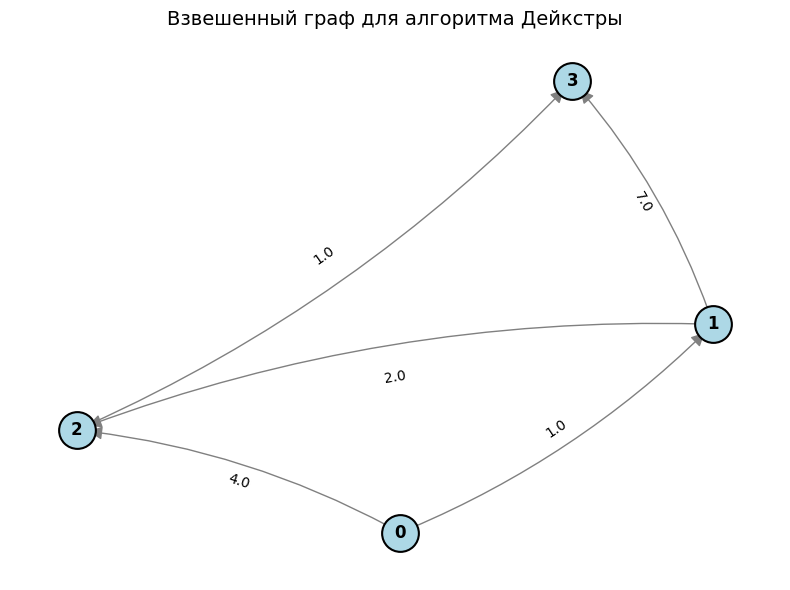

In [ ]:
G_dijkstra = nx.DiGraph()
G_dijkstra.add_weighted_edges_from(edges)

draw_graph(G_dijkstra, title='Взвешенный граф для алгоритма Дейкстры')

Запускаем алгоритм Дейкстры:

In [ ]:
source = 0

distances, predecessors = dijkstra(
    csgraph=A,
    directed=True,
    indices=source,
    return_predecessors=True
)

print("Источник:", source)
print("Кратчайшие расстояния:", distances)
print("Массив предшественников:", predecessors)

Источник: 0
Кратчайшие расстояния: [0. 1. 3. 4.]
Массив предшественников: [-9999     0     1     2]


Восстановление и анализ пути до вершины 3:

In [ ]:
target = 3
path = reconstruct_path(predecessors, source, target)

print(f"Кратчайший путь {source} -> {target}:", " -> ".join(map(str, path)))
print("Длина пути:", distances[target])

Кратчайший путь 0 -> 3: 0 -> 1 -> 2 -> 3
Длина пути: 4.0


Визуализация кратчайшего пути:

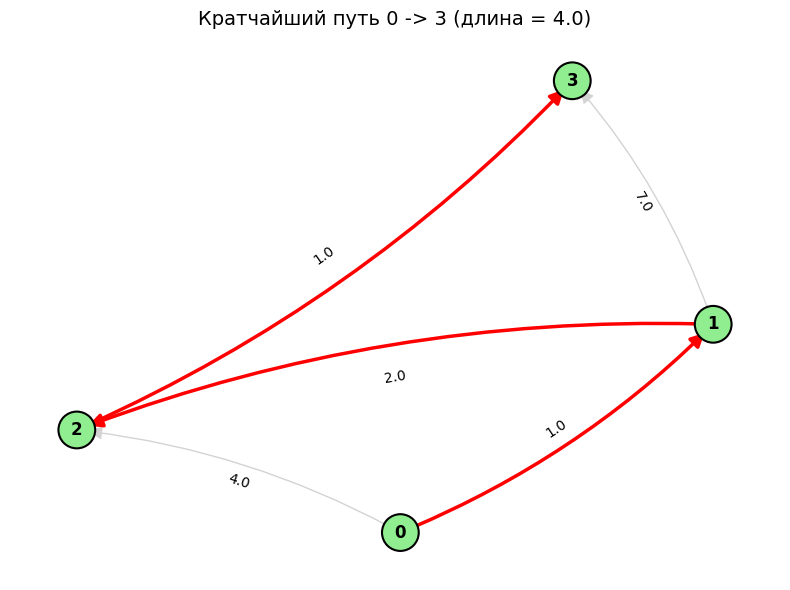

In [ ]:
path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

draw_graph(G_dijkstra,
           title=f'Кратчайший путь 0 -> 3 (длина = {distances[target]})',
           highlight_path=path,
           highlight_edges=path_edges)

Сравнение возможных путей до вершины 3:
- 0 → 1 → 3: длина = 1.0 + 7.0 = 8.0
- 0 → 2 → 3: длина = 4.0 + 1.0 = 5.0
- 0 → 1 → 2 → 3: длина = 1.0 + 2.0 + 1.0 = 4.0 (оптимальный)

---

## **8.2. Алгоритм Беллмана–Форда**

Алгоритм Беллмана–Форда работает даже при отрицательных весах рёбер (но при отсутствии отрицательных циклов).

Создадим граф с отрицательным ребром:

In [ ]:
from scipy.sparse.csgraph import bellman_ford

row = np.array([0, 0, 1, 2])
col = np.array([1, 2, 2, 3])
data = np.array([2.0, 5.0, -3.0, 1.0])  # ребро 1->2 имеет вес -3

A_negative = csr_matrix((data, (row, col)), shape=(4, 4))

print("Матрица смежности (есть отрицательное ребро 1->2):")
print(A_negative.toarray())

Матрица смежности (есть отрицательное ребро 1->2):
[[ 0.  2.  5.  0.]
 [ 0.  0. -3.  0.]
 [ 0.  0.  0.  1.]
 [ 0.  0.  0.  0.]]


Визуализируем граф с отрицательным ребром:

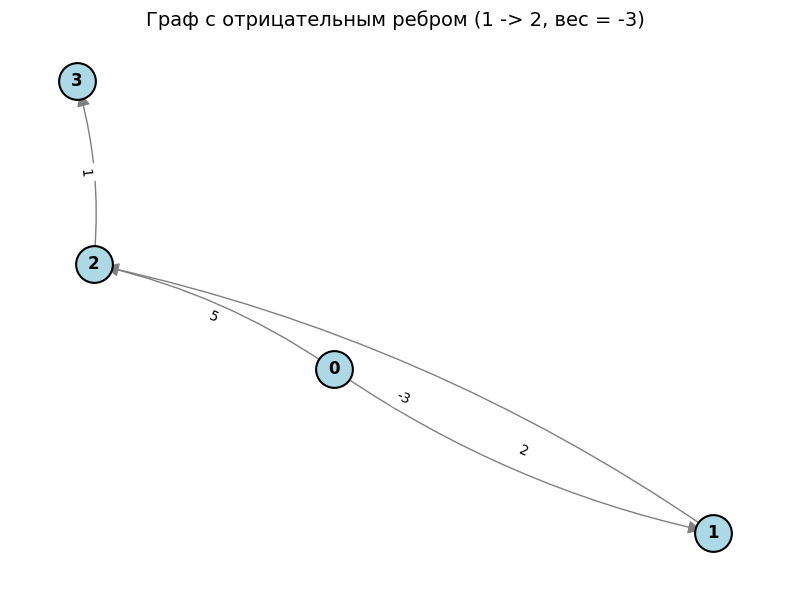

In [ ]:
G_bellman = nx.DiGraph()
G_bellman.add_weighted_edges_from([(0, 1, 2), (0, 2, 5), (1, 2, -3), (2, 3, 1)])

draw_graph(G_bellman, title='Граф с отрицательным ребром (1 -> 2, вес = -3)')

Запускаем Bellman-Ford:

In [ ]:
source = 0

dist_bf, pred_bf = bellman_ford(
    csgraph=A_negative,
    directed=True,
    indices=source,
    return_predecessors=True
)

print("Кратчайшие расстояния:", dist_bf)

Кратчайшие расстояния: [ 0.  2. -1.  0.]


Восстановление пути:

In [ ]:
target = 3
path_bf = reconstruct_path(pred_bf, source, target)

print(f"Путь {source} -> {target}:", " -> ".join(map(str, path_bf)))
print("Длина:", dist_bf[target])

Путь 0 -> 3: 0 -> 1 -> 2 -> 3
Длина: 0.0


Визуализация найденного пути:

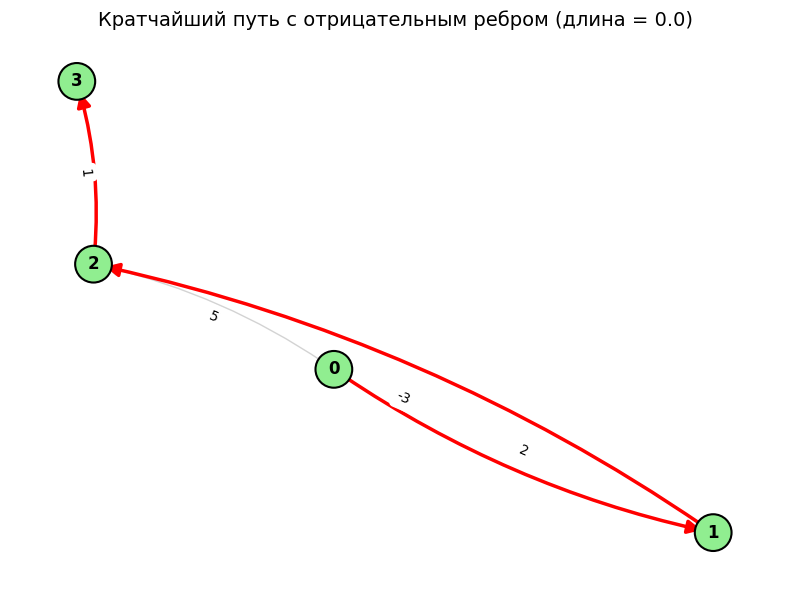

In [ ]:
path_edges_bf = [(path_bf[i], path_bf[i+1]) for i in range(len(path_bf)-1)]

draw_graph(G_bellman,
           title=f'Кратчайший путь с отрицательным ребром (длина = {dist_bf[target]})',
           highlight_path=path_bf,
           highlight_edges=path_edges_bf)

Благодаря отрицательному ребру путь 0 → 1 → 2 → 3 имеет длину 2.0 + (-3.0) + 1.0 = 0.0, что короче, чем прямой путь 0 → 2 → 3 с длиной 5.0 + 1.0 = 6.0.

---

## **8.3. Алгоритм Флойда–Уоршелла**

Алгоритм Флойда–Уоршелла находит кратчайшие расстояния между всеми парами вершин. Подходит для небольших графов (до нескольких тысяч вершин) из-за кубической сложности O(V³).

In [ ]:
from scipy.sparse.csgraph import floyd_warshall

dist_matrix = floyd_warshall(csgraph=A, directed=True)

print("Матрица кратчайших расстояний (строка i -> столбец j):")
print(dist_matrix)

Матрица кратчайших расстояний (строка i -> столбец j):
[[ 0.  1.  3.  4.]
 [inf  0.  2.  3.]
 [inf inf  0.  1.]
 [inf inf inf  0.]]


Примеры чтения матрицы:

In [ ]:
print("Расстояние от v0 до v3:", dist_matrix[0, 3])
print("Расстояние от v1 до v3:", dist_matrix[1, 3])
print("Расстояние от v3 до v0:", dist_matrix[3, 0], "(inf = недостижимо)")

Расстояние от v0 до v3: 4.0
Расстояние от v1 до v3: 3.0
Расстояние от v3 до v0: inf (inf = недостижимо)


---

## **8.4. Алгоритм Джонсона**

Алгоритм Джонсона эффективен для больших разреженных графов, когда нужны расстояния между всеми парами вершин и могут быть отрицательные веса.

In [ ]:
from scipy.sparse.csgraph import johnson

dist_johnson = johnson(csgraph=A_negative, directed=True)

print("Матрица кратчайших расстояний (Johnson):")
print(dist_johnson)

Матрица кратчайших расстояний (Johnson):
[[ 0.  2. -1.  0.]
 [inf  0. -3. -2.]
 [inf inf  0.  1.]
 [inf inf inf  0.]]


## **8.5. Сводная таблица: выбор алгоритма**

| Задача | Алгоритм | Функция | Сложность |
|--------|----------|---------|-----------|
| Один источник, веса ≥ 0 | Дейкстра | `dijkstra` | O((V+E) log V) |
| Один источник, отрицательные веса | Беллман–Форд | `bellman_ford` | O(V × E) |
| Все пары, малый граф | Флойд–Уоршелл | `floyd_warshall` | O(V³) |
| Все пары, большой разреженный граф | Джонсон | `johnson` | O(V×E + V² log V) |
| Невзвешенный граф | BFS | `breadth_first_order` | O(V + E) |

---

# **Часть 9. Дополнительные алгоритмы**

## **9.1. Минимальное остовное дерево (MST)**

Минимальное остовное дерево — подграф неориентированного связного графа, который содержит все вершины, является деревом (связен и не имеет циклов) и имеет минимальную сумму весов рёбер.

Применения: проектирование сетей, кластеризация, приближённые алгоритмы для задачи коммивояжёра.

Создадим граф:

In [ ]:
from scipy.sparse.csgraph import minimum_spanning_tree

row = np.array([0, 0, 1, 1, 1, 2, 3])
col = np.array([1, 2, 2, 3, 4, 4, 4])
data = np.array([2.0, 3.0, 1.0, 4.0, 5.0, 5.0, 1.0])

A_mst = csr_matrix((data, (row, col)), shape=(5, 5))
A_mst = A_mst + A_mst.T

print("Матрица смежности:")
print(A_mst.toarray())

Матрица смежности:
[[0. 2. 3. 0. 0.]
 [2. 0. 1. 4. 5.]
 [3. 1. 0. 0. 5.]
 [0. 4. 0. 0. 1.]
 [0. 5. 5. 1. 0.]]


Визуализируем исходный граф:

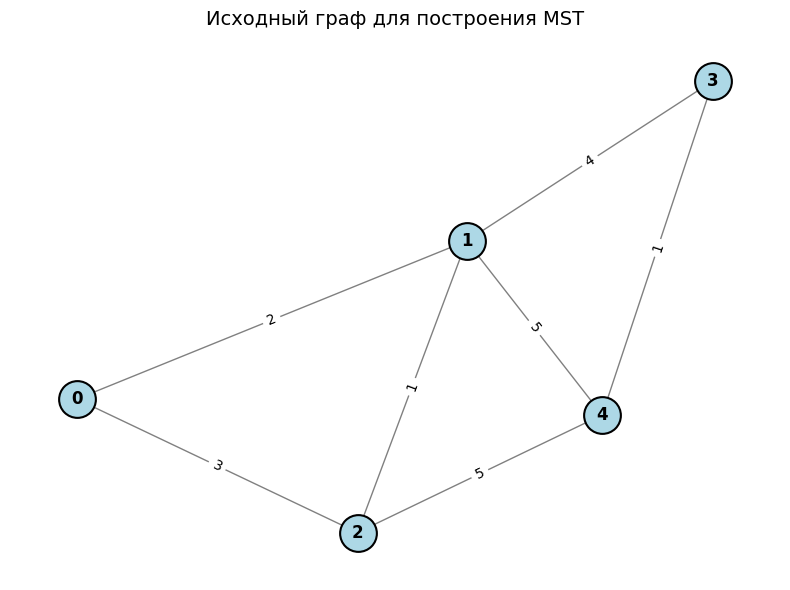

In [ ]:
G_mst = nx.Graph()
G_mst.add_weighted_edges_from([
    (0, 1, 2), (0, 2, 3), (1, 2, 1), (1, 3, 4), (1, 4, 5), (2, 4, 5), (3, 4, 1)
])

draw_graph(G_mst, title='Исходный граф для построения MST')

Находим MST:

In [ ]:
mst = minimum_spanning_tree(A_mst)

print("Минимальное остовное дерево:")
print(mst.toarray())

Минимальное остовное дерево:
[[0. 2. 0. 0. 0.]
 [0. 0. 1. 4. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]


Выводим рёбра MST и суммарный вес:

In [ ]:
mst_coo = mst.tocoo()
total_weight = 0

print("Рёбра MST:")
mst_edges_list = []
for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
    print(f"  {u} -- {v}, вес = {w}")
    total_weight += w
    mst_edges_list.append((u, v))

print("Суммарный вес MST:", total_weight)

Рёбра MST:
  0 -- 1, вес = 2.0
  1 -- 2, вес = 1.0
  1 -- 3, вес = 4.0
  3 -- 4, вес = 1.0
Суммарный вес MST: 8.0


Визуализация MST (рёбра дерева выделены красным):

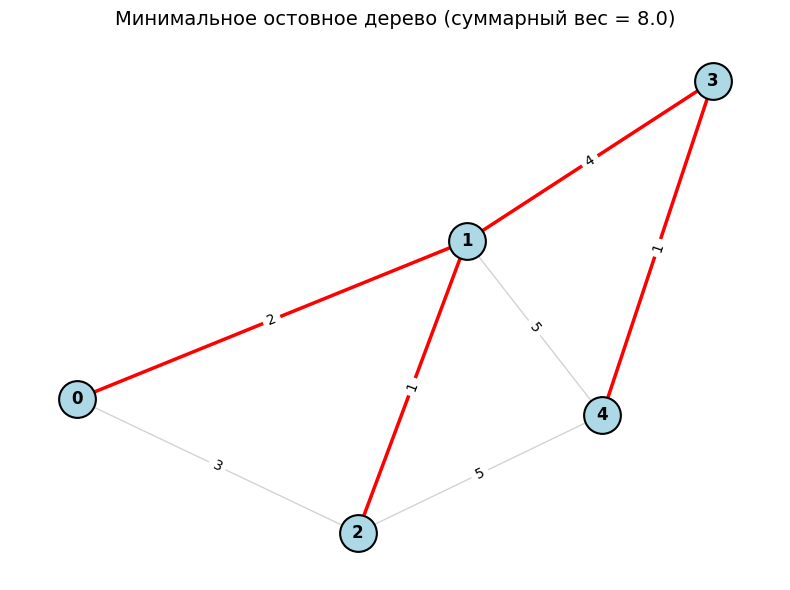

In [ ]:
draw_graph(G_mst,
           title=f'Минимальное остовное дерево (суммарный вес = {total_weight})',
           highlight_edges=mst_edges_list)

---

## **9.2. Максимальный поток**

Задача максимального потока: в сети с источником и стоком найти максимальный поток, не превышающий пропускные способности рёбер.



Применения: транспортные сети, сети связи, задачи о назначениях.



Создадим сеть с пропускными способностями:

In [ ]:
from scipy.sparse.csgraph import maximum_flow

row = np.array([0, 0, 1, 1, 2])
col = np.array([1, 2, 2, 3, 3])
capacity = np.array([10, 5, 15, 10, 10])

C = csr_matrix((capacity, (row, col)), shape=(4, 4))

print("Матрица пропускных способностей:")
print(C.toarray())

Матрица пропускных способностей:
[[ 0 10  5  0]
 [ 0  0 15 10]
 [ 0  0  0 10]
 [ 0  0  0  0]]


Визуализируем сеть (веса — пропускные способности):

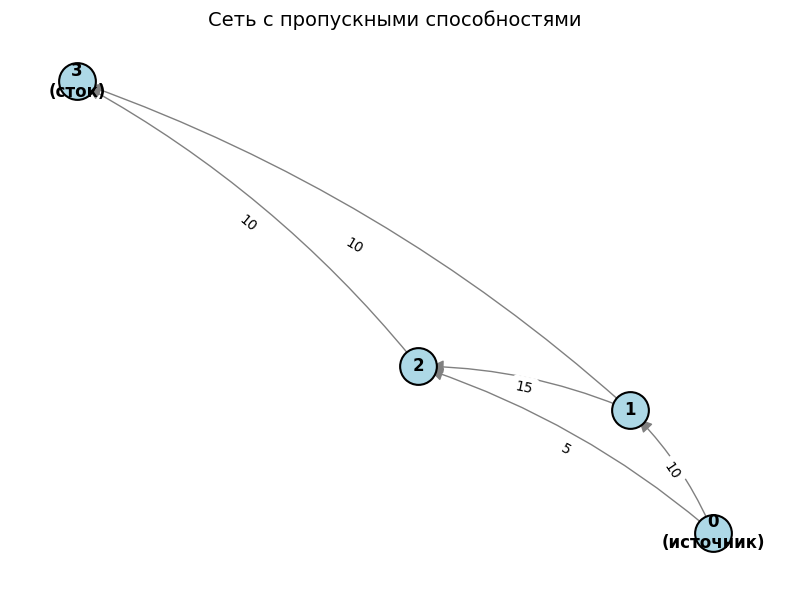

In [ ]:
G_flow = nx.DiGraph()
G_flow.add_weighted_edges_from([(0, 1, 10), (0, 2, 5), (1, 2, 15), (1, 3, 10), (2, 3, 10)])

node_labels = {0: '0\n(источник)', 1: '1', 2: '2', 3: '3\n(сток)'}
draw_graph(G_flow, title='Сеть с пропускными способностями', node_labels=node_labels)

Находим максимальный поток:

In [ ]:
source = 0
sink = 3

result = maximum_flow(csgraph=C, source=source, sink=sink)

print("Источник:", source)
print("Сток:", sink)
print("Максимальный поток:", result.flow_value)

Источник: 0
Сток: 3
Максимальный поток: 15


Потоки по рёбрам:

In [ ]:
flow_coo = result.flow.tocoo()

print("Потоки по рёбрам:")
for u, v, f in zip(flow_coo.row, flow_coo.col, flow_coo.data):
    if f > 0:
        cap = C[u, v]
        print(f"  {u} -> {v}: поток = {f} / {cap}")

Потоки по рёбрам:
  0 -> 1: поток = 10 / 10
  0 -> 2: поток = 5 / 5
  1 -> 3: поток = 10 / 10
  2 -> 3: поток = 5 / 10


---

# **Часть 10. Практический проект: маршрут по городу**

Применим все изученные концепции к реальной задаче — построению кратчайшего маршрута по дорожной сети города.

## **10.1. Обзор технологий**

| Технология | Назначение |
|------------|------------|
| OSMnx | Загрузка дорожной сети из OpenStreetMap |
| NetworkX | Промежуточное представление графа |
| SciPy | Быстрый поиск кратчайших путей |
| Folium | Визуализация маршрута на интерактивной карте |

## **10.2. Установка дополнительных библиотек**

```bash
pip install osmnx folium
```

## **10.3. Реализация проекта**

### **Шаг 1. Импорт библиотек**

In [ ]:
%%capture
!pip install osmnx folium

In [ ]:
import osmnx as ox
import networkx as nx
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
import folium
import time

### **Шаг 2. Настройка OSMnx**

OSMnx позволяет загружать реальные дорожные сети из OpenStreetMap. Включим кэширование для ускорения повторных запросов.

In [ ]:
ox.settings.log_console = True
ox.settings.use_cache = True

### **Шаг 3. Загрузка дорожной сети**

Загружаем граф автомобильных дорог для выбранного города. Параметр `network_type="drive"` означает только автомобильные дороги. Можно использовать `"walk"` для пешеходных или `"bike"` для велосипедных.

In [ ]:
place_name = "Санкт-Петербург, Россия"

G = ox.graph_from_place(place_name, network_type="drive")

print("Город:", place_name)
print("Вершин (перекрёстков):", len(G.nodes()))
print("Рёбер (участков дорог):", len(G.edges()))

Город: Санкт-Петербург, Россия
Вершин (перекрёстков): 19034
Рёбер (участков дорог): 42034


### **Шаг 4. Проекция в метрическую систему координат**

Исходные координаты OSM — широта и долгота (WGS84). Для корректного расчёта расстояний в метрах нужно спроецировать граф в метрическую систему координат (UTM).

In [ ]:
G_proj = ox.project_graph(G)

### **Шаг 5. Создание отображения вершин в индексы**

Вершины OSM имеют уникальные идентификаторы (большие числа). Для работы с матрицами SciPy нам нужны последовательные индексы 0, 1, 2, ...

In [ ]:
nodes = list(G_proj.nodes())
n = len(nodes)

node_to_idx = {node: i for i, node in enumerate(nodes)}
idx_to_node = {i: node for i, node in enumerate(nodes)}

print("Создано отображение для", n, "вершин")

Создано отображение для 19034 вершин


### **Шаг 6. Конвертация в разреженную матрицу SciPy**

Преобразуем граф NetworkX в CSR-матрицу, используя длину дороги как вес ребра.

In [ ]:
A = nx.to_scipy_sparse_array(
    G_proj,
    nodelist=nodes,
    weight="length",
    dtype=float,
    format="csr"
)

density = A.nnz / (n * n) * 100
sparse_memory = (A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 1024**2
dense_memory = n * n * 8 / 1024**2

print("Матрица создана:", A.shape)
print("Ненулевых элементов:", A.nnz)
print("Плотность:", round(density, 4), "%")
print("Память (разреженная):", round(sparse_memory, 1), "МБ")
print("Память (если бы плотная):", round(dense_memory, 1), "МБ")
print("Экономия памяти:", round(dense_memory / sparse_memory), "x")

Матрица создана: (19034, 19034)
Ненулевых элементов: 41638
Плотность: 0.0115 %
Память (разреженная): 0.8 МБ
Память (если бы плотная): 2764.1 МБ
Экономия памяти: 3541 x


### **Шаг 7. Задание точек маршрута**

Зададим координаты начальной и конечной точек маршрута. Можно использовать любые координаты в пределах загруженного города.

In [ ]:
origin_coords = (59.939095, 30.315868)
destination_coords = (59.927, 30.360)

### **Шаг 8. Поиск ближайших вершин графа**

Находим вершины графа, ближайшие к заданным координатам. Используем исходный граф G (в координатах WGS84), а не спроецированный.

In [ ]:
origin_node = ox.nearest_nodes(G, X=origin_coords[1], Y=origin_coords[0])
dest_node = ox.nearest_nodes(G, X=destination_coords[1], Y=destination_coords[0])

origin_idx = node_to_idx[origin_node]
dest_idx = node_to_idx[dest_node]

print("Начальная вершина: OSM ID", origin_node, "-> индекс", origin_idx)
print("Конечная вершина: OSM ID", dest_node, "-> индекс", dest_idx)

Начальная вершина: OSM ID 1573813663 -> индекс 6181
Конечная вершина: OSM ID 8299929835 -> индекс 6979


### **Шаг 9. Поиск кратчайшего пути алгоритмом Дейкстры**

Запускаем алгоритм Дейкстры и замеряем время выполнения.

In [ ]:
start_time = time.perf_counter()

distances, predecessors = dijkstra(
    csgraph=A,
    directed=True,
    indices=origin_idx,
    return_predecessors=True
)

elapsed_time = time.perf_counter() - start_time

distance_meters = distances[dest_idx]
distance_km = distance_meters / 1000

print("Время вычисления:", round(elapsed_time * 1000, 1), "мс")
print("Кратчайшее расстояние:", round(distance_meters), "м (", round(distance_km, 2), "км)")

Время вычисления: 4.9 мс
Кратчайшее расстояние: 4162 м ( 4.16 км)


### **Шаг 10. Восстановление пути**

Используем ранее определённую функцию `reconstruct_path` для восстановления последовательности вершин.

In [ ]:
path_indices = reconstruct_path(predecessors, origin_idx, dest_idx)

if not path_indices:
    print("Путь не найден!")
else:
    path_nodes = [nodes[i] for i in path_indices]
    print("Путь найден!")
    print("Количество вершин на пути:", len(path_nodes))

Путь найден!
Количество вершин на пути: 44


### **Шаг 11. Визуализация маршрута на карте**

Создаём интерактивную карту с помощью Folium. Для отображения используем координаты из исходного графа G (WGS84).

Создание карты:

In [ ]:
center_lat = G.nodes[origin_node]["y"]
center_lon = G.nodes[origin_node]["x"]

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="CartoDB Positron"
)

Извлечение координат маршрута:

In [ ]:
route_coordinates = []
for node_id in path_nodes:
    lat = G.nodes[node_id]["y"]
    lon = G.nodes[node_id]["x"]
    route_coordinates.append((lat, lon))

Рисуем линию маршрута:

In [ ]:
folium.PolyLine(
    locations=route_coordinates,
    color="red",
    weight=5,
    opacity=0.8,
    tooltip=f"Кратчайший путь: {round(distance_km, 2)} км"
).add_to(m)


Добавляем маркеры начальной и конечной точек:

In [ ]:
folium.Marker(
    location=(G.nodes[origin_node]["y"], G.nodes[origin_node]["x"]),
    popup="Старт",
    icon=folium.Icon(color="green", icon="play")
).add_to(m)

folium.Marker(
    location=(G.nodes[dest_node]["y"], G.nodes[dest_node]["x"]),
    popup="Финиш",
    icon=folium.Icon(color="blue", icon="stop")
).add_to(m)

Отображение карты (в Jupyter Notebook просто выведите переменную `m`):

In [ ]:
m

Для сохранения карты в HTML-файл:

In [ ]:
m.save("shortest_route.html")

---

## **10.4. Пояснения к коду выше**

### **Почему используем два графа (G и G_proj)?**

| Граф | Система координат | Использование |
|------|-------------------|---------------|
| G | WGS84 (широта/долгота) | Поиск ближайших узлов, визуализация |
| G_proj | UTM (метры) | Построение матрицы с корректными длинами |

### **Почему SciPy быстрее NetworkX в этой задаче?**

1. **Разреженная матрица** — дорожная сеть очень разрежена
2. **Оптимизированный C-код** — алгоритм Дейкстры реализован на низком уровне
3. **Минимальные накладные расходы** — нет Python-словарей и объектов

---